# 020 · 한국어는 왜 토큰이 더 드는가 — 그리고 그것이 학습 설정을 정한다

** CPU로 실행 가능

## 이 노트북의 산출물
`artifacts/tokens/token_cost.json` — **`420` 학습에서 쓸 `max_seq_len` 권고값**을 여기서 정한다.
이 노트북을 건너뛰면  `max_seq_len`을 감으로 정하게 된다.

## 학습목표
1. 동일 한국어 문장의 모델별 토큰 수(**fertility**)를 측정·비교할 수 있다
2. 토큰 수가 만드는 3가지 비용을 계산할 수 있다 — 추론 요금 / 컨텍스트 한계 / **학습 예산**
3. 길이 분포의 p95로 `max_seq_len`을 정할 수 있다

In [1]:
# --- 패키지 설치 (Colab) ---
# 설치 후 "런타임 다시 시작" 안내가 나오면 재시작하고, 다음 셀부터 이어서 실행한다.
!pip install -q transformers==4.57.1 datasets==4.0.0 accelerate==1.10.1 \
    peft==0.17.1 trl==0.23.0 bitsandbytes==0.47.0 tiktoken==0.11.0
!apt-get install -y fonts-nanum -qq > /dev/null   # matplotlib 한글 폰트

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# --- 저장소 클론 및 루트 이동 (Colab) ---
from pathlib import Path

if not Path("common/config.py").exists():
    !git clone -q https://github.com/ironmanciti/LLM_FineTuning_Lecture.git
    %cd LLM_FineTuning_Lecture
print("저장소 루트:", Path.cwd())

from common import config as C, env, artifacts as art
env.set_seed(C.SEED)

/content/LLM_FineTuning_Lecture
저장소 루트: /content/LLM_FineTuning_Lecture


42

In [ ]:
# --- Google Drive 연결: artifacts/ 영속화 (Colab) ---
# 노트북마다 런타임(VM)이 다르므로, 산출물을 Drive에 두어야 다음 노트북에서 읽을 수 있다.
import shutil
from pathlib import Path

try:
    from google.colab import drive  # Colab이 아니면 ImportError

    drive.mount("/content/drive")

    DRIVE_ART = Path("/content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts")
    DRIVE_ART.mkdir(parents=True, exist_ok=True)

    local_art = Path("artifacts")
    if not local_art.is_symlink():
        if local_art.exists():  # 이미 로컬에 쓴 결과가 있으면 Drive로 이관
            shutil.copytree(local_art, DRIVE_ART, dirs_exist_ok=True)
            shutil.rmtree(local_art)
        local_art.symlink_to(DRIVE_ART)
    print("artifacts ->", local_art.resolve())
except ImportError:
    print("Colab이 아니므로 로컬 artifacts/ 를 그대로 사용합니다.")


---
## 1. fertility — 한 어절이 몇 토큰이 되는가

**fertility = 토큰 수 ÷ 어절 수.** 값이 클수록 같은 내용에 토큰이 더 든다.
영어는 대체로 1.2\~1.5, 한국어는 토크나이저에 따라 2\~4까지 벌어진다.

In [3]:
from transformers import AutoTokenizer

SAMPLES_KO = [
    "딥러닝을 활용한 자연어처리 과정에서 LoRA로 파인튜닝을 해봤습니다.",
    "고객이 어제 주문한 상품의 배송 상태를 조회하여 알려주시기 바랍니다.",
    "본 계약의 해지는 상대방에게 서면으로 통지한 날로부터 30일 후에 효력이 발생한다.",
    "이번 분기 영업이익이 전년 동기 대비 12.4퍼센트 증가한 것으로 집계되었습니다.",
]
SAMPLES_EN = [
    "I fine-tuned an open-weight model with LoRA in this natural language processing course.",
    "Please look up the delivery status of the item the customer ordered yesterday.",
    "Termination of this agreement takes effect 30 days after written notice to the other party.",
    "Operating profit for the quarter rose 12.4 percent from the same period last year.",
]

tokenizers = {}
for label, ref in C.TOKENIZER_ZOO.items():
    if label.startswith("tiktoken:"):
        try:
            import tiktoken
            enc = tiktoken.get_encoding(ref)
            tokenizers[label] = ("tiktoken", enc)
            print(f"  [OK] {label}")
        except Exception as e:
            print(f"  [건너뜀] {label}: {e}")
        continue
    try:
        tokenizers[label] = ("hf", AutoTokenizer.from_pretrained(ref))
        print(f"  [OK] {label}")
    except Exception as e:
        print(f"  [건너뜀] {label}: {type(e).__name__}")


def count(kind_tok, text):
    kind, tok = kind_tok
    if kind == "tiktoken":
        return len(tok.encode(text))
    return len(tok(text, add_special_tokens=False)["input_ids"])

  [OK] tiktoken:cl100k_base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

  [OK] KLUE-RoBERTa


In [4]:
import pandas as pd

rows = []
for label, kt in tokenizers.items():
    ko_tok = sum(count(kt, s) for s in SAMPLES_KO)
    en_tok = sum(count(kt, s) for s in SAMPLES_EN)
    ko_words = sum(len(s.split()) for s in SAMPLES_KO)
    en_words = sum(len(s.split()) for s in SAMPLES_EN)
    rows.append({
        "토크나이저": label,
        "한국어 토큰": ko_tok,
        "영어 토큰": en_tok,
        "한국어 fertility": round(ko_tok / ko_words, 2),
        "영어 fertility": round(en_tok / en_words, 2),
        "한/영 배율": round(ko_tok / en_tok, 2),
    })

df = pd.DataFrame(rows).sort_values("한국어 fertility")
display(df)
print("\n※ '한/영 배율'은 같은 내용을 한국어로 쓸 때 토큰이 몇 배 드는가다.")

,토크나이저,한국어 토큰,영어 토큰,한국어 fertility,영어 fertility,한/영 배율
2,KLUE-RoBERTa,89,128,2.41,2.33,0.70
1,Qwen2.5,110,70,2.97,1.27,1.57
0,tiktoken:cl100k_base,159,68,4.30,1.24,2.34



※ '한/영 배율'은 같은 내용을 한국어로 쓸 때 토큰이 몇 배 드는가다.


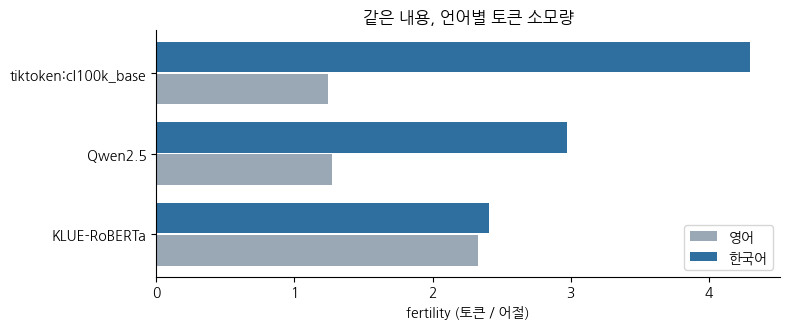

In [5]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 등록 (첫 설치 셀에서 fonts-nanum 설치됨)
matplotlib.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 3.4))
y = range(len(df))
ax.barh([i - 0.2 for i in y], df["영어 fertility"], height=0.38, label="영어", color="#9aa7b4")
ax.barh([i + 0.2 for i in y], df["한국어 fertility"], height=0.38, label="한국어", color="#2f6f9f")
ax.set_yticks(list(y)); ax.set_yticklabels(df["토크나이저"])
ax.set_xlabel("fertility (토큰 / 어절)")
ax.set_title("같은 내용, 언어별 토큰 소모량")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 주의 — 흔한 오해

**fertility가 낮다 = 좋은 모델이 아니다.** 토큰 효율과 성능은 **별개 축**이다.
한국어 특화 토크나이저를 쓴 작은 모델이 다국어 대형 모델보다 답을 잘 못 할 수 있다.
여기서 얻는 것은 "성능 판단"이 아니라 **"예산 계산"**이다.

---
## 2. 세 가지 비용

### (1) 추론 요금

In [7]:
PRICING = {
    "예시 대형 API":  {"in": 3.00, "out": 15.00},
    "예시 소형 API":  {"in": 0.15, "out": 0.60},
    "자체 호스팅 sLLM": {"in": 0.00, "out": 0.00},   # GPU 시간 비용은 별도
}

N_REQ = 10_000
IN_TOK, OUT_TOK = 800, 150   # 요청당 평균

print(f"{N_REQ:,}건 처리 비용 (입력 {IN_TOK} / 출력 {OUT_TOK} 토큰 가정)\n")
for name, p in PRICING.items():
    cost = N_REQ * (IN_TOK * p["in"] + OUT_TOK * p["out"]) / 1e6
    print(f"  {name:<16} ${cost:>8,.2f}")
print("\n※ 자체 호스팅은 토큰 요금이 0이지만 GPU 시간·운영 인력이 든다.")
print("   이 비교가 '파인튜닝을 할 것인가'(2일차 §3.7) 판단의 한 축이다.")

10,000건 처리 비용 (입력 800 / 출력 150 토큰 가정)

  예시 대형 API        $   46.50
  예시 소형 API        $    2.10
  자체 호스팅 sLLM      $    0.00

※ 자체 호스팅은 토큰 요금이 0이지만 GPU 시간·운영 인력이 든다.
   이 비교가 '파인튜닝을 할 것인가'(2일차 §3.7) 판단의 한 축이다.


### (2) 컨텍스트 한계

In [8]:
DOC_CHARS = 2000   # 문서 1건 평균 글자 수

print(f"컨텍스트 창에 들어가는 문서 수 (문서당 {DOC_CHARS}자 가정)\n")
print(f"{'토크나이저':<16}{'문서당 토큰':>12}{'8K':>7}{'32K':>7}{'128K':>7}")
sample = SAMPLES_KO[2] * (DOC_CHARS // len(SAMPLES_KO[2]) + 1)
sample = sample[:DOC_CHARS]
for label, kt in tokenizers.items():
    t = count(kt, sample)
    print(f"{label:<16}{t:>12,}{8192//t:>7}{32768//t:>7}{131072//t:>7}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1000 > 512). Running this sequence through the model will result in indexing errors


컨텍스트 창에 들어가는 문서 수 (문서당 2000자 가정)

토크나이저                 문서당 토큰     8K    32K   128K
tiktoken:cl100k_base       1,783      4     18     73
Qwen2.5                1,347      6     24     97
KLUE-RoBERTa           1,000      8     32    131


### (3) 학습 예산 — 이 노트북의 본론

`max_seq_len`을 512로 잡으면 그보다 긴 학습 샘플은 **뒤가 잘린다.**
뒤에는 정답과 EOS가 있다. 잘린 샘플로 학습하면 모델이 **멈추는 법을 못 배운다.**

그래서 길이 분포를 보고 정해야 한다. 기준은 **p95** — 95%의 샘플이 온전히 들어가는 길이다.

In [9]:
from datasets import load_dataset

# 실제 학습에 쓸 데이터로 길이를 잰다. 샘플 문장으로 재면 의미가 없다.
try:
    ds = load_dataset(C.DATASET_ID, split=f"train[:{C.N_TRAIN}]")
    print(f"{C.DATASET_ID} {len(ds)}건 로드")
    print("컬럼:", ds.column_names)
except Exception as e:
    print(f"[대체] 데이터셋 로드 실패({type(e).__name__}). 샘플을 복제해 진행합니다.")
    ds = None

README.md: 0.00B [00:00, ?B/s]

squad_kor_v1/train-00000-of-00001.parque(…):   0%|          | 0.00/11.6M [00:00<?, ?B/s]

squad_kor_v1/validation-00000-of-00001.p(…):   0%|          | 0.00/1.16M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60407 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5774 [00:00<?, ? examples/s]

KorQuAD/squad_kor_v1 2000건 로드
컬럼: ['id', 'title', 'context', 'question', 'answers']


In [10]:
import json
import numpy as np
from common import chat

def build_texts(dataset, n=None):
    """410과 동일한 형식으로 조립해야 길이 측정이 유효하다."""
    out = []
    if dataset is None:
        for i in range(400):
            s = SAMPLES_KO[i % len(SAMPLES_KO)]
            out.append((s * 6, "질문입니까?", json.dumps({"answer": "예", "evidence": s},
                                                        ensure_ascii=False)))
        return out
    for r in (dataset if n is None else dataset.select(range(min(n, len(dataset))))):
        ans = r["answers"]["text"][0] if r["answers"]["text"] else ""
        target = json.dumps({"answer": ans, "evidence": ans}, ensure_ascii=False)
        out.append((r["context"], r["question"], target))
    return out

triples = build_texts(ds)
print(f"{len(triples)}건으로 길이 측정")

tok_for_train = None
for label, (kind, t) in tokenizers.items():
    if kind == "hf" and "Qwen" in label:
        tok_for_train = t; used = label; break
if tok_for_train is None:
    from transformers import AutoTokenizer
    tok_for_train = AutoTokenizer.from_pretrained(C.MODEL_ID); used = C.MODEL_ID
print("학습 대상 토크나이저:", used)

2000건으로 길이 측정
학습 대상 토크나이저: Qwen2.5


In [11]:
lengths, prompt_lens, answer_lens = [], [], []
for ctx, q, target in triples:
    msgs = chat.build_messages(q, system=C.SYSTEM_PROMPT, context=ctx)
    ex = chat.build_example(tok_for_train, msgs, target, max_len=10**6)
    lengths.append(ex["n_total"]); prompt_lens.append(ex["n_prompt"]); answer_lens.append(ex["n_answer"])

a = np.array(lengths)
stats = {
    "n": int(a.size), "mean": float(a.mean()), "median": float(np.median(a)),
    "p90": float(np.percentile(a, 90)), "p95": float(np.percentile(a, 95)),
    "p99": float(np.percentile(a, 99)), "max": int(a.max()),
    "prompt_mean": float(np.mean(prompt_lens)), "answer_mean": float(np.mean(answer_lens)),
}
for k, v in stats.items():
    print(f"  {k:<12}{v:>10.1f}" if isinstance(v, float) else f"  {k:<12}{v:>10}")

  n                 2000
  mean             513.3
  median           469.0
  p90              684.0
  p95              775.0
  p99             1199.3
  max               1768
  prompt_mean      490.8
  answer_mean       22.5


In [12]:
# max_seq_len 후보별로 몇 %가 잘리는지
print(f"{'max_seq_len':>12}{'온전한 비율':>12}{'잘리는 건수':>12}")
candidates = [256, 384, 512, 768, 1024, 1536, 2048]
for m in candidates:
    keep = float((a <= m).mean())
    print(f"{m:>12}{100*keep:>11.1f}%{int((a > m).sum()):>12}")

# p95를 64의 배수로 올림한 값을 권고값으로
import math
recommended = int(math.ceil(stats["p95"] / 64) * 64)
recommended = min(recommended, 2048)
print(f"\n권고 max_seq_len = {recommended}  (p95 {stats['p95']:.0f} 을 64 배수로 올림)")
print(f"이 값에서 {100*float((a <= recommended).mean()):.1f}% 의 샘플이 온전히 들어간다.")

 max_seq_len      온전한 비율      잘리는 건수
         256        0.0%        2000
         384        9.9%        1802
         512       64.8%         703
         768       94.5%         109
        1024       98.0%          39
        1536       99.4%          13
        2048      100.0%           0

권고 max_seq_len = 832  (p95 775 을 64 배수로 올림)
이 값에서 96.7% 의 샘플이 온전히 들어간다.


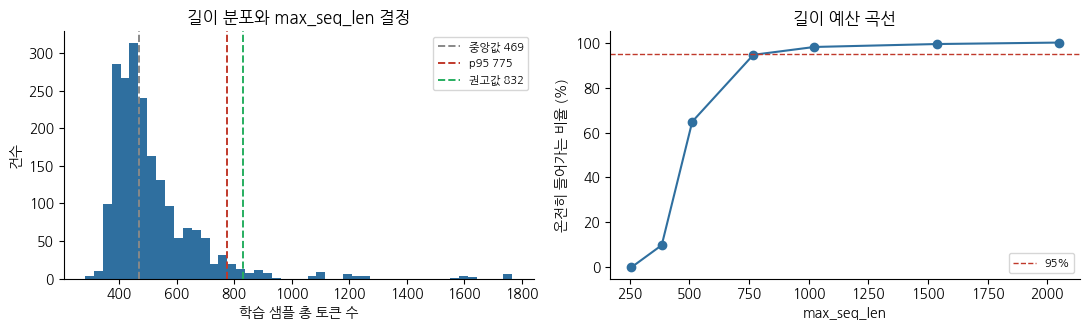

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(a, bins=48, color="#2f6f9f")
for v, c, l in [(stats["median"], "#888", "중앙값"), (stats["p95"], "#c0392b", "p95"),
                (recommended, "#27ae60", "권고값")]:
    axes[0].axvline(v, color=c, ls="--", lw=1.4, label=f"{l} {v:.0f}")
axes[0].set_xlabel("학습 샘플 총 토큰 수"); axes[0].set_ylabel("건수")
axes[0].set_title("길이 분포와 max_seq_len 결정"); axes[0].legend(fontsize=8)

axes[1].plot(candidates, [100 * float((a <= m).mean()) for m in candidates], "o-", color="#2f6f9f")
axes[1].axhline(95, color="#c0392b", ls="--", lw=1, label="95%")
axes[1].set_xlabel("max_seq_len"); axes[1].set_ylabel("온전히 들어가는 비율 (%)")
axes[1].set_title("길이 예산 곡선"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 왜 p95인가

- **p99로 잡으면** 소수의 긴 샘플 때문에 `max_seq_len`이 커지고, VRAM은 시퀀스 길이에
  거의 비례해 늘어난다. T4에서는 학습이 안 돌게 된다.
- **p50으로 잡으면** 절반이 잘린다. 잘린 샘플은 EOS를 못 배우므로 **응답이 끝나지 않는
  모델**이 된다 — 3일차 `430`의 `clean_stop_pct`가 낮게 나오는 원인이다.
- p95는 타협점이고, **넘치는 5%는 `410`에서 버린다**(잘린 채로 학습시키지 않는다).

---
## 3. 산출물 저장 — `420`이 이 값을 읽는다

In [14]:
payload = {
    "tokenizer_used": used,
    "model_id": C.MODEL_ID,
    "dataset": C.DATASET_ID,
    "n_samples_measured": stats["n"],
    "length_stats": stats,
    "coverage": {str(m): round(100 * float((a <= m).mean()), 2) for m in candidates},
    "recommended_max_seq_len": recommended,
    "fertility_table": rows,
    "note": "recommended_max_seq_len 은 p95를 64의 배수로 올린 값. 420에서 이 값을 사용한다.",
}
p = art.save_json(art.token_cost_path(), payload)
print("저장:", p)
print("\n다음: 410에서 이 값으로 데이터셋을 만들고, 초과 샘플을 버린다.")

저장: /content/LLM_FineTuning_Lecture/artifacts/tokens/token_cost.json

다음: 410에서 이 값으로 데이터셋을 만들고, 초과 샘플을 버린다.


---
## 정리

| 잰 것 | 어디에 쓰이는가 |
|---|---|
| fertility | 모델 후보 비교의 **한 축**(2일차 §3.6). 성능 축과 혼동하지 말 것 |
| 요금·컨텍스트 | 파인튜닝 vs API 판단(2일차 §3.7-2) |
| **p95 → `max_seq_len`** | **`420` 학습 설정. VRAM과 직결(§3.8-4)** |

### 제출
`artifacts/tokens/token_cost.json`. 최종 리포트(`450`)에 자동 반영된다.